<a href="https://colab.research.google.com/github/andrearivera019/Analitica-de-Negocios/blob/main/Primer_Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Caso De Estudio**
Una entidad del sector de la salud está buscando implementar un modelo de analítica de datos que le permita clasificar pacientes de acuerdo con la probabilidad que tengan de padecer diabetes, con el fin de mejorar los procesos de diagnóstico temprano y apoyar la toma de decisiones médicas.


Para lo anterior, se va a utilizar la información clínica de los pacientes, y esta tiene variables y relacionadas con indicadores de salud y una variable de resultados que indica si el paciente presenta o no diabetes. Las variables que se utilizarán son:


**Embarazos:** Indica la cantidad de embarazos que ha tenido el paciente.

**Glucosa:** Representa la concentración de glucosa en plasma en sangre. Es una de las variables más importantes para el diagnóstico de diabetes, porque niveles elevados de glucosa indican problemas de regulación del azúcar en la sangre.

**Presión Arterial:** Es la presión arterial diastólica medida en mmHg.

**Grosor de la piel:** Mide el grosor del pliegue cutáneo del triceps en milímetros; se utiliza como un indicador indirecto de la cantidad de grasa corporal que tiene una persona.

**Insulina:** Indica el nivel de insulina en sangre, es una hormona fundamental para regular los niveles de glucosa en la sangre (valores anormales pueden indicar resistencia a la insulina).

**IMC:** Mide la relación entre el peso y la altura de una persona, es utilizado para determinar si una persona tiene peso normal, sobrepeso u obesidad.

**Función de pedigree de diabetes:** Mide la probabilidad de desarrollar diabetes basada en antecedentes familiares.

**Edad:** Es la edad del paciente en el momento en que se tomaron los datos clínicos, y está medida en años.

**Resultado:** Es la variable objetivo del modelo e indica si el paciente tiene o no diabetes (1 = el paciente presenta diabetes; 0 = el paciente no presenta diabetes)


Se van a llevar a cabo tres modelos de análisis y clasificación para comparar un desempeño en la predicción de diabtes; el primero va a ser el modelo de Naive Bayes, el segundo será el modelo de árboles de decisión y por último se va a realizar un modelo de clusterización K-Means.




## **Modelo Naive Bayes**


*0. Se procede con la carga de las librerías de trabajo*

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*1. Se cargan los datos de trabajo de la base de datos DiabetesDatabase*

In [ ]:
nxl = '/content/drive/MyDrive/Analítica de Negocios/DiabetesDatabase.xlsx'
XDB = pd.read_excel(nxl,sheet_name=0)


#Seleccionar las variables de trabajo
XD = XDB [['Embarazos', 'Glucosa', 'Presión arterial', 'Grosor de la piel', 'Insulina', 'IMC', 'Función de pedigrí de diabetes', 'Edad']]
yd = XDB [['Resultado']]
XDB.head()

,Embarazos,Glucosa,Presión arterial,Grosor de la piel,Insulina,IMC,Función de pedigrí de diabetes,Edad,Resultado
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2288.000,33,1


*2. Se procede a  implementar el Modelo Naive Bayes*

In [ ]:
np.set_printoptions(suppress = True, precision = 3)
mnb = GaussianNB()
mnb.fit(XD,yd)

#Medidas de las variables
u = mnb.theta_
sigma = mnb.var_ ; sigma = np.sqrt(sigma)
print("'Embarazos', 'Glucosa', 'Presión arterial', 'Grosor de la piel', 'Insulina', 'IMC', 'Función de pedigrí de diabetes', 'Edad'")
print(u)
print()

print('Las deviaciones son:')
print(sigma)
print()
print()

print('Los límites superiores de las variables son: ')
print(u + sigma)
print()
print()

print('Los límites inferiores de las variables son: ')
print(u - sigma)
print()
print()

'Embarazos', 'Glucosa', 'Presión arterial', 'Grosor de la piel', 'Insulina', 'IMC', 'Función de pedigrí de diabetes', 'Edad'
[[  3.298 109.98   68.184  19.664  68.792  30.304  54.733  31.19 ]
 [  4.866 141.257  70.825  22.164 100.336  35.143 131.803  37.067]]

Las deviaciones son:
[[  3.014  26.115  18.045  14.875  98.766   7.682 274.412  11.656]
 [  3.734  31.88   21.452  17.647 138.43    7.249 404.202  10.948]]


Los límites superiores de las variables son: 
[[  6.312 136.095  86.229  34.539 167.558  37.986 329.145  42.846]
 [  8.6   173.137  92.276  39.811 238.766  42.392 536.006  48.015]]


Los límites inferiores de las variables son: 
[[   0.284   83.865   50.139    4.789  -29.974   22.622 -219.679   19.534]
 [   1.131  109.377   49.373    4.517  -38.094   27.893 -272.399   26.119]]




**Análisis de Resultados**

A partir de los resultados obtenidos, en primer lugar, al analizar las medias de las variables se puede ver que los apcientes con diabetes presentan valores más altos en variables que son claves para la enfermedad. En el caso de la glucosa es considerablemente mayor en el grupo con diabetes (141.257) en comparación con el grupo sin diabetes (109.98); y esto puede estar realcionado con que la glucosa elevada es uno de los principales indicadores de esta enfermedad; de igual manera, el IMC también muestra valores más altos en pacientes con diabetes (35.143 frente a 30.304), lo que sugiera una posible relación entre el sobrepeso u obesidad y la presencia de diabetes.

Al igual que la insulina, el grosor de la piel y la edad también presentan valores promedio mayores en el grupo de apcientes con diabetes, indicando que estas variables pueden contribuir a la diferenciación entre los pacientes diagnosticados y los no diagnosticados.

Por otro lado, con respecto a las desviaciones estándar, muestran que existe una variabilidad considerable en algunas variables, especialmente en insulina y función de pedigree de diabetes, indicando que los valores de estas variables pueden variar significativamente entre pacientes; y esta variabilidad es importante para el modelo, porque influye en la forma en que se calculan las probabilidades de clasificación.

Finalmente, los límites superiores e inferiores dejan identificar el rango dentro del que se espera que se encuentren los valores de cada varaible para cada clase; estos límites ayudan al modelo a determinar qué tan probable es que un nuevo paciente pertenezca a cada grupo, dependiendo de qué tan cerca se ecneuntren sus valores respecto a las distribuciones observadas en los datos de entrenamiento.

*3.Evaluación del Modelo por medio de la matriz de confusión*

In [ ]:
ydp = mnb.predict(XD)
cm = confusion_matrix(yd,ydp)
print(cm)
print()

VN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]; VP = cm[1,1]; TDatos = len(XDB)

#1. Exactitud
Ex = (VP + VN) / TDatos
print("Exactitud: ", Ex)
print()

#2. Tasa Error
TEr = (FP + FN) / TDatos
print("Tasa Error: ", TEr)
print()

#3. Sensibilidad
Se = VP / (VP + FN)
print("Sensibilidad: ", Se)
print()

#4. Especificidad
Es = VN / (VN + FP)
print("Especificidad: ", Es)
print()

#5. Precisión
Pr = VP / (VP + FP)
print("Precisión: ", Pr)
print()

#6. Predicción Negativa
PrN = VN / (VN + FN)
print("Predicción Negativa: ", PrN)
print()


[[426  74]
 [112 156]]

Exactitud:  0.7578125

Tasa Error:  0.2421875

Sensibilidad:  0.582089552238806

Especificidad:  0.852

Precisión:  0.6782608695652174

Predicción Negativa:  0.79182156133829



**Análisis de Resultados**

El modelo clasificó de manera correcta 426 pacientes que no tienen diabetes, mientras que 74 pacientes fueron clasificados incorrectamente como si tuvieran diabetes. Por otro lado, 156 pacientes con diabetes fueron correctamente identificados, mientras que 112 pacientes que sí tenían diabetes fueron clasificados como si no la tuvieran.

Con respecto al desempeño general, el modelo tuvo una exactitud del 75% aproximadamente indicando que el modelo tiene un modelo bueno para clasificar a los apcientes. Si se analiza la tasa de error, se puede ver que tuene un 24% aproximadamente, mostrando que el porcentaje de pacientres que fueron clasificados incorrectamente, aunque no es extremadamente alto, muestra que existe un margen de mejora en la capacidad predictiva del modelo.

Con respecto a la sensibilidad es de 58% aproximadamente y muestra los pacientes que realmente tienen diabetes, es moderado, por lo que el modelo no detecta todos los casos positivos y deja algunos pacientes con diabetes sin identificar.

La especificidad es de 85% aproximadamente, indicando que el modelo es muy efectivo identificando a los pacientes que no tienen diabetes, sugiere que el modelo tiene un mejor desempeño detectando pacientes sanos que detectando pacientes enfermos.

La precisión del modelo es de 67% aproximadamente e indica que que cuando el modelo predice un paciente con diabetes, aproximadamente este porcentaje es una predicción positiva.

Finalmente, el valor predictivo negativo es de aproximadamente 79% e indica que cuando el modelo predice que un paciente no tiene diabates, esta predicción es correcta aproximadament eel 79% de las veces.

*4. Evaluar al paciente*

In [ ]:
XDp = [2, 85, 65, 29, 94, 39.6, 0.93, 27]
ydc = mnb.predict([XDp])
print(ydc)
print()

if ydc == 1:
  print("La persona analizada tiene diabetes")
else:
  print("La persona analizada NO tiene diabetes")

print()


[0]

La persona analizada NO tiene diabetes



**Análisis de Resultados**

Después de analizar el paciente con los datos ingresados [2, 85, 65, 29, 94, 39.6, 0.93, 27] se arroja un resultado de 0, es decir, el paciente no presenta diabetes, lo que indica que con unos valores en estas variables como las que se ingresaron, la persona no tiene características asociadas que el modelo pueda reconocer para decir que tiene diabetes.

## **Modelo de Árboles de Decisión**

*0. Carga de las librerías de trabajo específicas*

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

*1. Carga de los datos de trabajo*

In [ ]:
XD2 = XDB.iloc[:,[0, 1, 2, 3, 4, 5, 6, 7]]
yd2 =XDB.iloc [:,8]
display(XD2)
display(yd2)

,Embarazos,Glucosa,Presión arterial,Grosor de la piel,Insulina,IMC,Función de pedigrí de diabetes,Edad
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2288.000,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


,Resultado
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


*2. Implementación del modelo del árbol*

In [ ]:
mar = DecisionTreeClassifier(criterion = 'gini', max_depth = 4)
mar.fit(XD2,yd2)

ydp2 = mar.predict(XD2)

cm2 = confusion_matrix(yd2,ydp2)
VN2 = cm2[0,0]; FP2 = cm2[0,1]; FN2 = cm2[1,0]; VP2 = cm2[1,1]

display (cm2)
print()
print()

#Métricas de desempeño
#1. Exactitud
Ex2 = (VP2 + VN2) / len (XD2)
print("La exactitud es:",Ex2)
print()

#2. sensibilidad
Sen2 = VP2 / (VP2 + FN2)
print("La sensibilidad es:",Sen2)
print()

#3. Especificidad
Spe2 = VN2 / (VN2 + FP2)
print("La especificidad es:",Spe2)
print()

#4. Precisión
Pre2 = VP2 / (VP2 + FP2)
print("La precisión es:",Pre2)
print()

#5. Predicción Negativa
PreNeg2 = VN2 / (VN2 + FN2)
print("La precisión negativa es:",PreNeg2)
print()

array([[459,  41],
       [119, 149]])



La exactitud es: 0.7916666666666666

La sensibilidad es: 0.5559701492537313

La especificidad es: 0.918

La precisión es: 0.7842105263157895

La precisión negativa es: 0.7941176470588235



**Análisis de Resultados**

Con la matriz de confusión se puede ver que el modelo clasificó correctamente 459 pacientes como no diabéticos (verdaderos negativos) y a 149 pacientes como diabéticos (verdaderos positivos); esto muestra que el modelo es altamente eficiente en el reconocimiento de casos negativos. Sin embargo, la matriz también evidencia 41 falsos positivos, lo cual indica casos en el que el modelo predijo diabetes en individuos que no la presentan, y 119 falsos negativos, que representan el grupo de pacientes con diabetes que el mdoelo erróneamente clasificó como sanos.

La exactitud de es de 79% aproximadamente, indica una capacidad de clasificación muy buena, por encima del promedio. Por otro lado, la sensibilidad es del 55% aproximadamente, mostrando una oportunidad de mejora, este valor es que el modelo solo está detectando poco más de la mitad de los casos positivos reales.

La especificidad dio un 91% aproximadamente y evidencia una alta competencia para descartar correctamente a los pacientes sanos, lo que reduce eficazmente la tasa de falsas alarmas. La precisión  fue de 78% aproximadamente y la predicción negativa fue de 79% aproximadamente, sugiriendo que cuando el modelo emite un diagnóstivo, existe una consistencia estadística similar tanto para confirmar como para descartar la enfermedad.

*3. Despliegue del Árbol de Decisión*

In [ ]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data

np.random.seed(42)

vs = ['Embarazos', 'Glucosa', 'Presión arterial', 'Grosor de la piel', 'Insulina', 'IMC', 'Función de pedigrí de diabetes', 'Edad']
dot_data = export_graphviz (mar, feature_names = vs)
graph = graph_from_dot_data(dot_data)

graph.write_png('Parcialdef.png')

True

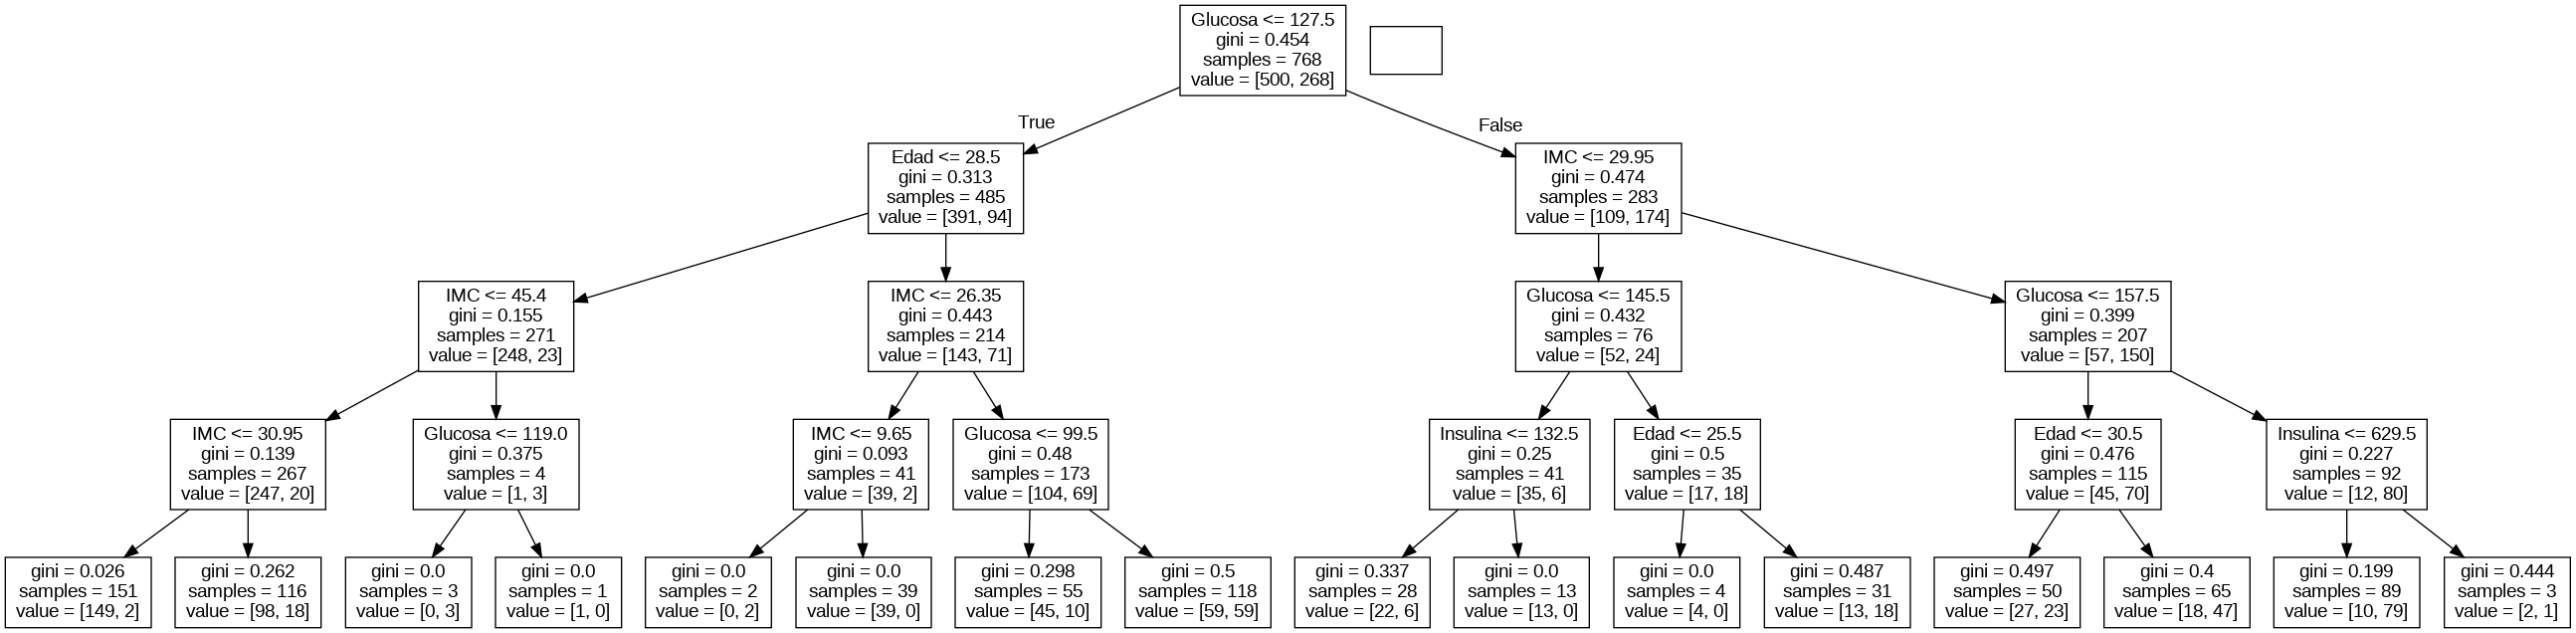



*4. Despliegue de los nodos del árbol*

In [ ]:
tree_rules = export_text(mar, feature_names = vs)
print(tree_rules)

|--- Glucosa <= 127.50
|   |--- Edad <= 28.50
|   |   |--- IMC <= 45.40
|   |   |   |--- IMC <= 30.95
|   |   |   |   |--- class: 0
|   |   |   |--- IMC >  30.95
|   |   |   |   |--- class: 0
|   |   |--- IMC >  45.40
|   |   |   |--- Glucosa <= 119.00
|   |   |   |   |--- class: 1
|   |   |   |--- Glucosa >  119.00
|   |   |   |   |--- class: 0
|   |--- Edad >  28.50
|   |   |--- IMC <= 26.35
|   |   |   |--- IMC <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- IMC >  9.65
|   |   |   |   |--- class: 0
|   |   |--- IMC >  26.35
|   |   |   |--- Glucosa <= 99.50
|   |   |   |   |--- class: 0
|   |   |   |--- Glucosa >  99.50
|   |   |   |   |--- class: 0
|--- Glucosa >  127.50
|   |--- IMC <= 29.95
|   |   |--- Glucosa <= 145.50
|   |   |   |--- Insulina <= 132.50
|   |   |   |   |--- class: 0
|   |   |   |--- Insulina >  132.50
|   |   |   |   |--- class: 0
|   |   |--- Glucosa >  145.50
|   |   |   |--- Edad <= 25.50
|   |   |   |   |--- class: 0
|   |   |   |--- Edad >  25.50


**Análisis de Resultados**

A partir del árbol de decisión se puede ver un total de 768 registros, donde 500 pacientes no presentan diabetes y 268 sí presentan la enfermedad.

En el nodo raíz el árbol divide por Glucosa <= 127.5, y esto muestra que el nivel de glucosa es la variable más importante para la clasificación.

Luego, el modelo utiliza variables como la edad, el IMC y la insulina para continuar dividiendo y mejorar la capacidad de clasificación. Se observa que niveles elevados de glucosa y valores altos de IMC aumentan la probabilidad de presentar diabetes, mientras que niveles más bajos tienden a asociarse con pacientes sin la enfermedad.

Dentro del árbol se identifican 6 nodos puros (gini = 0), lo que significa que en esas condiciones el modelo clasifica a los pacientes con 100% de certeza dentro del conjunto analizado.

De acuerdo con el árbol de decisión, se pueden encontrar 6 nodos puros, en los que el gini = 0, y se siguen las siguientes reglas de decisión:


**Nodo 1 =** If Glucosa <= 127.5 and Edad <= 28.5 and IMC > 45.4 and Glucosa ≤ 119.5; la decisión va a ser de [0,3] --> 0% / 100% (100% para diabetes)


**Nodo 2 =** If Glucosa <= 127.5 and Edad <= 28.5 and IMC > 45.4 and Glucosa > 119; la decisión va a ser de [1,0] --> 100% / 0% (100% para no diabetes)


**Nodo 3 =** If Glucosa ≤ 127.5 and Edad > 28.5 and IMC ≤ 26.35 and IMC ≤ 9.65; la decisión va a ser de [0,2] --> 0% / 100% (100% para diabetes)


**Nodo 4 =** If Glucosa ≤ 127.5 and Edad > 28.5 and IMC ≤ 26.35 and IMC > 9.65; la decisión va a ser de [39,0] --> 100% / 0% (100% para no diabetes)


**Nodo 5 =** If Glucosa > 127.5 and IMC ≤ 29.95 and Glucosa ≤ 145.5 and Insulina > 132.5; la decisión va a ser de [13,0] --> 100% / 0% (100% para no diabetes)


**Nodo 6 =** If Glucosa > 127.5 and IMC ≤ 29.95 and Glucosa > 145.5 and Edad ≤ 25.5; la decisión va a ser de [4,0] --> 100% / 0% (100% para no diabetes)

*5. Evaluar al paciente*

In [ ]:
XDp2 = [2, 85, 65, 29, 94, 39.6, 0.93, 27]
ydc2 = mar.predict([XDp2])
print(ydc)
print()

if ydc2 == 1:
  print("La persona analizada tiene diabetes")
else:
  print("La persona analizada NO tiene diabetes")

print()

[0]

La persona analizada NO tiene diabetes



***Análisis de Resultados***

Después de analizar el paciente con los datos ingresados [2, 85, 65, 29, 94, 39.6, 0.93, 27] se arroja un resultado de 0, es decir, el paciente no presenta diabetes, lo que indica que con unos valores en estas variables como las que se ingresaron, la persona no tiene características asociadas que el modelo pueda reconocer para decir que tiene diabetes.

## **Modelo Clustering k-Means**

*0. Se cargan las librerías específicas*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

*1. Carga de los datos de trabajo*

<Axes: >

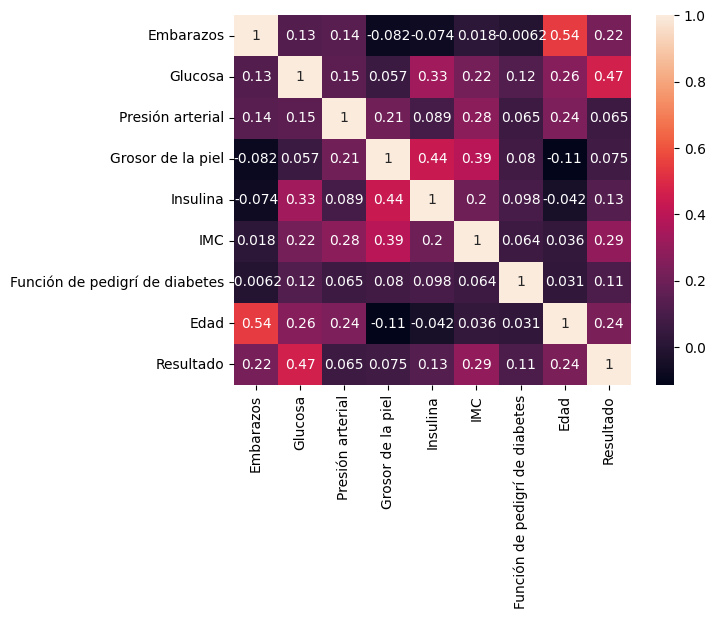

In [ ]:
XD3 = XDB.iloc[:,[0, 1, 2, 3, 4, 5, 6, 7]]
yd3 = XDB.iloc[:,8]

#Correlación entre las variables
XDB2 = XDB.iloc[:,[0, 1, 2, 3, 4, 5, 6, 7, 8]]
sns.heatmap(XDB2.corr(), annot = True)


**Análisis de Resultados**

La matriz de correlación muestra la relación lineal entre las diferentes variables de salud y la variable de salida. Se puede evidenciar que la Glucosa tiene  correlación positiva más alta (0.47), consolidándose como el predictor individual más crítico para determinar la presencia de diabetes. Le siguen en importancia el IMC (0.29) y la Edad (0.24), lo cual indica que, aunque influyen en el diagnóstico, su peso estadístico es inferior al nivel de glucosa en sangre.

Es importante observar correlaciones significativas entre las variables de entrada como el vínculo entre Embarazos y Edad (0.54) y Grosor de la piel con Insulina (0.44), lo que sugiere que el modelo no solo analiza factores aislados, sino perfiles de salud complejos.

Finalmente, el hecho de que variables como la presión arterial (0.065) o el grosor de la piel (0.075) presenten correlaciones cercanas a cero respecto al Resultado implica que estas características tienen un impacto marginal en la predicción final de los modelos implementados.

*2. Implementación del modelo K-Means*

In [ ]:
np.random.seed(42)
NC = 5
mkm = KMeans(n_clusters = NC, random_state = 42)
mkm.fit(XD3,yd3)

#Características de cada grupo
tabla = pd.DataFrame(mkm.cluster_centers_,columns = XD3.columns)
display(tabla)

#Porcentajes
ydp3 = mkm.labels_
NDc = np.bincount(ydp3)
print()
print("El número de datos por cluster es: ", NDc)

,Embarazos,Glucosa,Presión arterial,Grosor de la piel,Insulina,IMC,Función de pedigrí de diabetes,Edad
0,3.490826,128.339450,71.321101,30.229358,158.000000,33.951835,0.479950,31.366972
1,4.487179,133.948718,76.948718,24.769231,95.717949,34.702564,1200.871795,36.512821
2,3.968017,113.409382,67.275053,14.718550,14.405117,30.660981,0.384576,33.716418
3,1.375000,140.625000,66.500000,28.250000,197.625000,31.675000,1944.500000,29.000000
4,4.264706,156.794118,71.764706,31.970588,434.470588,34.764706,0.441647,35.941176



El número de datos por cluster es:  [218  39 469   8  34]


**Análisis de Resultados**

El modelo de K-Means se aplicó con 5 clusters, con el objetivo de agrupar pacientes que presentan valores promedio específicos en las variables analizadas. A partir de los resultados, se observa que el cluster 2 es el grupo más grande con 469 pacientes, seguido por el cluster 0 con 218 pacientes, mientras que los clusters 1, 4 y 3 contienen una cantidad mucho menor de registros. Esto indica que la mayoría de los pacientes del conjunto de datos comparten características similares a las representadas por el cluster 2.

El cluster 4 presenta los valores más altos de glucosa (156.79) y de insulina (434.47), lo que indica que los pacientes de este grupo tienen niveles más elevados en estas variables. También se observa que el cluster 3 presenta valores altos de glucosa (140.63) e insulina (197.63), aunque es un grupo muy pequeño con solo 8 registros. En contraste, el cluster más grande (el 2) muestra los valores más bajos de glucosa (113.41) e insulina (14.41) en comparación con los otros grupos, lo que sugiere que este cluster representa pacientes con características más cercanas a valores normales dentro del conjunto de datos.

*3. Porcentajes de personas con enfermedad*

In [ ]:
XDB2["Cluster"] = ydp3
display (XDB2)

NApr = XDB2.groupby('Cluster').agg({'Resultado': lambda x: (x==1).sum()})
NPrn = XDB2.groupby('Cluster').agg({'Resultado': lambda x: (x==0).sum()})

#Decisión en porcentaje
NApr2 = NApr / (NApr + NPrn); NPrn2 = NPrn / (NApr + NPrn)
df2 = pd.DataFrame(np.column_stack((NApr,NPrn)),columns = ['Positivo', 'Negativo'])
display(df2)

,Embarazos,Glucosa,Presión arterial,Grosor de la piel,Insulina,IMC,Función de pedigrí de diabetes,Edad,Resultado,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,2
1,1,85,66,29,0,26.6,0.351,31,0,2
2,8,183,64,0,0,23.3,0.672,32,1,2
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2288.000,33,1,3
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0
764,2,122,70,27,0,36.8,0.340,27,0,2
765,5,121,72,23,112,26.2,0.245,30,0,0
766,1,126,60,0,0,30.1,0.349,47,1,2


,Positivo,Negativo
0,86,132
1,24,15
2,135,334
3,3,5
4,20,14


**Análisis de Resultados**

La base de datos utilizada contiene un total de 768 pacientes, de los cuales 268 presentan diabetes y 500 no presentan la enfermedad. A partir del modelo de clustering K-Means con 5 clusters, se identificaron diferentes perfiles de pacientes según sus características de salud. El cluster 3 presenta el mayor porcentaje de pacientes con diabetes, con aproximadamente 66.7%, lo que indica que en este grupo se concentra el mayor riesgo de la enfermedad. Por otro lado, el cluster 2 muestra el menor porcentaje de diabetes, con aproximadamente 13%, por lo que la mayoría de los pacientes en este grupo no presentan la enfermedad. Los clusters 0 y 4 muestran proporciones cercanas entre pacientes con y sin diabetes, mientras que el cluster 1 tiene una mayor proporción de pacientes sin diabetes (alrededor de 63.5%). En general, el análisis de los clusters permite identificar diferentes perfiles de riesgo dentro de la población, facilitando la segmentación de pacientes y apoyando la toma de decisiones en el diagnóstico y prevención de la diabetes.

*4. Gráfica de los clusters utilizando las variables Embarazos y Edad (correlación más alta)*

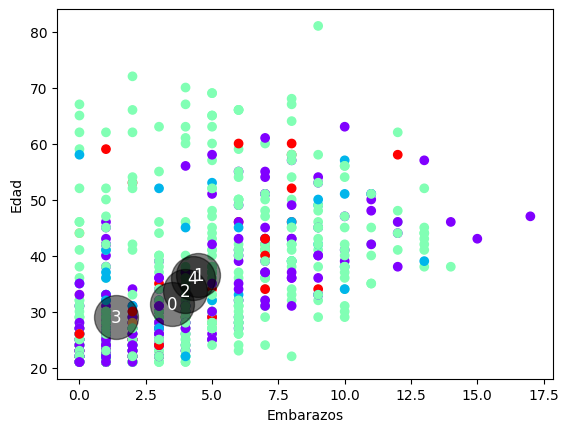

In [ ]:
centers = mkm.cluster_centers_
embarazos = np.array(XD.iloc[:,0]); edad = np.array(XD.iloc[:,7])

plt.figure()
plt.scatter(pregnancies, age, c=mkm.labels_, cmap='rainbow')
plt.scatter(centers[:,0], centers[:,7], c='black', s=1000, alpha=0.5)
plt.xlabel("Embarazos")
plt.ylabel("Edad")

# Añadir números a los centros
for i, center in enumerate(centers):
  plt.text(center[0], center[7], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()

*5. Evaluación de un paciente*

In [ ]:
XDp3 = np.array([2, 85, 65, 29, 94, 39.6, 0.93, 27])
ydp4 = mkm.predict(XDp3.reshape(1,-1))
NCl = ydp4[0]
print('La nueva persona pertenece al cluster: ',ydp4)
print()
print('El porcentaje de que la persona tenga un resultado positivo es: ', NApr2.iloc[NCl])
print()
print('El porcentaje de que la persona tenga un resultado negativo es: ', NPrn2.iloc[NCl])

La nueva persona pertenece al cluster:  [0]

El porcentaje de que la persona tenga un resultado positivo es:  Resultado    0.394495
Name: 0, dtype: float64

El porcentaje de que la persona tenga un resultado negativo es:  Resultado    0.605505
Name: 0, dtype: float64


**Análisis de Resultados**

El modelo K-Means asignó a la nueva paciente al cluster 0. Dentro de ese grupo, el análisis de los datos indica que aproximadamente 39.45% de los casos presentan un resultado positivo de diabetes, mientras que 60.55% presentan un resultado negativo. Esto significa que, según las características de la paciente, su perfil es más similar al de pacientes que no tienen diabetes, ya que la mayoría de los individuos en ese cluster tienen resultado negativo.